In [1]:
# import classy module
from classy import Class

In [2]:
# create instance of the class "Class"
LambdaCDM = Class()
# pass input parameters
# LambdaCDM.set({'omega_b':0.0223828,'omega_cdm':0.1201075,'h':0.67810,'A_s':2.100549e-09,'n_s':0.9660499,'tau_reio':0.05430842})
LambdaCDM.set({'omega_b':0.02237,'omega_cdm':0.1200,'h':0.6736,'A_s':2.0830e-9,'n_s':0.9649,'tau_reio':0.0568, 'k_pivot': 0.05, 'N_ur':3.046, 'T_cmb': 2.7255})
LambdaCDM.set({'output':'tCl,pCl,lCl,mPk','lensing':'yes','P_k_max_1/Mpc':3.0, 'z_max_pk': 1.0})

# run class
LambdaCDM.compute()

In [3]:
# uncomment to get plots displayed in notebook
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from math import pi

In [4]:
import numpy as np

# This function is used to "cut" a function in regions of positive and negative values
# such that we can plot it in log log
def plot_segments(x, y, color, legend):
    segments = []
    current_segment = [0]  # Start from the first index

    for i in range(1, len(y)):
        if (y[i] > 0) != (y[i - 1] > 0):  # Sign change
            current_segment.append(i)
            segments.append(current_segment)
            current_segment = [i]
    current_segment.append(len(y))  # Add the last segment
    segments.append(current_segment)

    for segment in segments:
        start, end = segment[0], segment[1]
        x_segment = x[start:end]
        y_segment = y[start:end]
        if np.all(y_segment > 0):
            plt.plot(x_segment, y_segment, linestyle='-', color=color, label=f'$B>0$, {legend}')
        elif np.all(y_segment < 0):
            plt.plot(x_segment, np.abs(y_segment), linestyle='--', color=color, label=f'$B<0$, {legend}')

In [5]:
# Don't use IR resummed powerspectra (yet)
use_IR_resum = 0

h = LambdaCDM.h()                                   # get reduced Hubble for conversions to 1/Mpc

# galaxy bias:
b1, b2, bG2 = 1.5, -1., 0.35

# noise bias:
n_bar = 0.000779126064152255
d1, d2, P_eps = 1., b1/2., 1./n_bar # to match Dennis' noise contribution: https://arxiv.org/pdf/2204.13628 eq. 2.20
# d1, d2, P_eps = 1., 1., 1e3

# size of k and z arrays
k_size      = 100
z_size      = 1


k_min, k_max = 0.0005, 0.5
z_min, z_max = 0.95, 1.

k = np.logspace(np.log10(k_min), np.log10(k_max), k_size)
#k = np.logspace(np.log1, -1, k_size)
z = np.linspace(z_min, z_max, z_size)

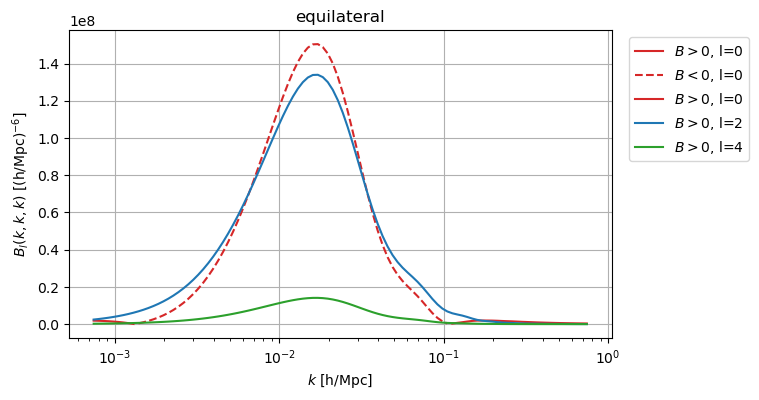

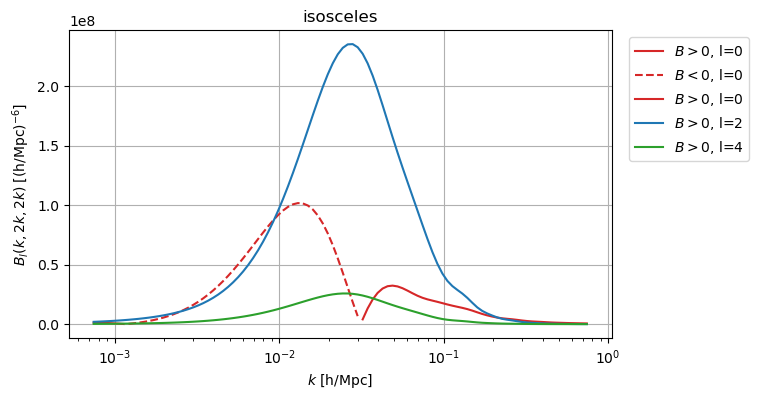

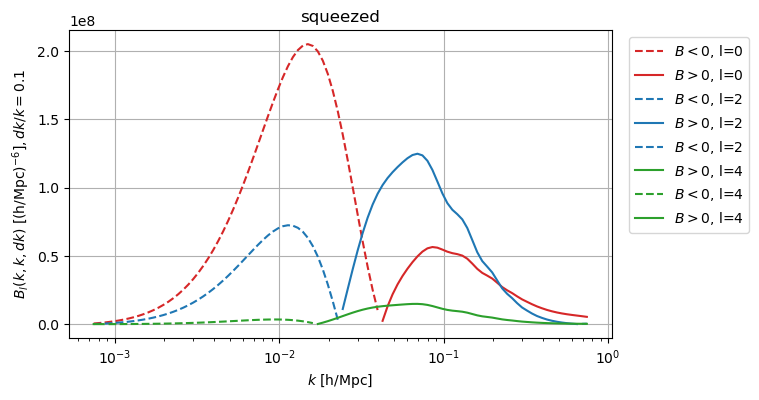

In [6]:
triangle_types = ["equi", "iso", "squeezed"]        # 3 types of triangle configs that we are interest in

# multipole l
l_s = [0, 2, 4]

colors = ["tab:red", "tab:blue", "tab:green"]

for type in triangle_types:
    plt.figure(figsize=(7, 4))
    for l_idx, l in enumerate(l_s):
        Bk_l = LambdaCDM.get_bk_lin_multipoles_configs(use_IR_resum, b1, b2, bG2, d1, d2, P_eps, type, k, l, z, k_size, z_size)
        Bk_l_1D = Bk_l[:,0]
        plot_segments(k/h, Bk_l_1D*h**6, colors[l_idx], f"l={l}")
    plt.xscale("log")
    #plt.yscale("log")
    plt.xlabel("$k$ [h/Mpc]")
    if type == "equi":
        plt.title("equilateral")
        plt.ylabel("$B_l(k, k, k)$ [(h/Mpc)$^{-6}]$")
    elif type == "iso":
        plt.title("isosceles")
        plt.ylabel("$B_l(k, 2k, 2k)$ [(h/Mpc)$^{-6}]$")
    elif type == "squeezed":
        plt.title("squeezed")
        plt.ylabel("$B_l(k, k, dk)$ [(h/Mpc)$^{-6}], dk/k=0.1$")
    plt.grid()
    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))  # Moves legend outside
    plt.savefig(f"Bispectrum_{type}", bbox_inches="tight")
    plt.show()




/var/folders/1t/6lvnjwb12mq1gyh7dlscmql00000gn/T/ipykernel_75798/1794599419.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  B0_diff, B2_diff, B4_diff, k1_arr, k2_arr, k3_arr = LambdaCDM.bispectrum_comparison_Dennis(data_file_name, n_rows, use_IR_resum, b1, b2, bG2, d1, d2, P_eps, z)


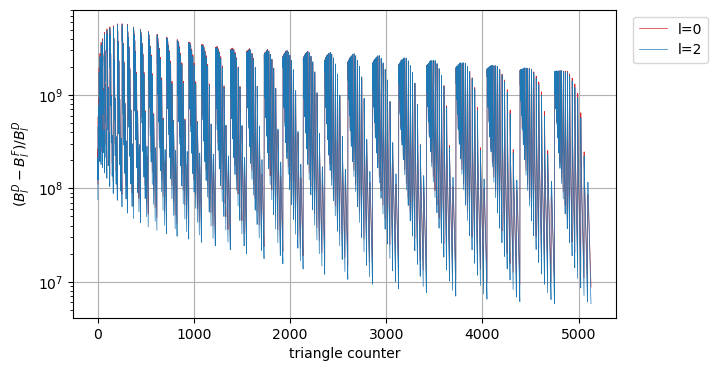

In [13]:
data_file_name = "/Users/fynn/Desktop/Uni/Master/Masters-thesis/Bell_z0p95.txt"
n_rows = 5130


n_triag = np.arange(1,n_rows)
B0_diff, B2_diff, B4_diff, k1_arr, k2_arr, k3_arr = LambdaCDM.bispectrum_comparison_Dennis(data_file_name, n_rows, use_IR_resum, b1, b2, bG2, d1, d2, P_eps, z)

plt.figure(figsize=(7, 4))
plt.plot(n_triag, np.array(B0_diff), linewidth=0.5, color=colors[0], label="l=0")
plt.plot(n_triag, B2_diff, linewidth=0.5, color=colors[1], label="l=2")
#plt.plot(n_triag, B4_diff, linewidth=0.5, color=colors[2], marker=".", label="l=4")


plt.yscale("log")
plt.xlabel("triangle counter")
plt.ylabel("$(B_l^D-B_l^F)/B_l^D$")
plt.grid()
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))  # Moves legend outside
plt.show()


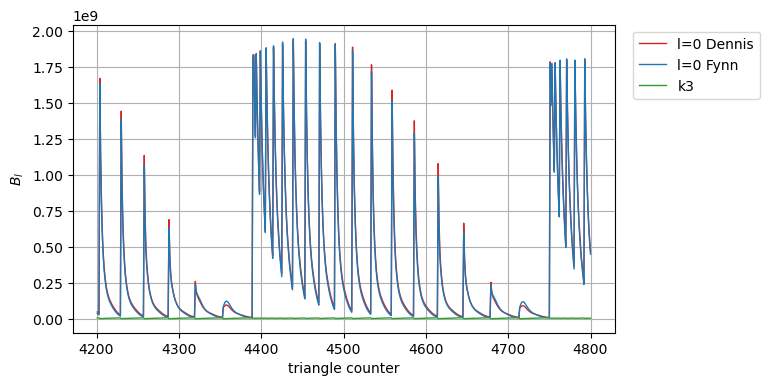

In [14]:

plt.figure(figsize=(7, 4))
plt.plot(n_triag[4200:4800], (B0_diff[4200:4800]), linewidth=1, color=colors[0], label="l=0 Dennis")
plt.plot(n_triag[4200:4800], B2_diff[4200:4800], linewidth=1, color=colors[1], label="l=0 Fynn")
plt.plot(n_triag[4200:4800], (k3_arr[4200:4800])*1e8, linewidth=1, color=colors[2], label="k3")
#plt.plot(n_triag, B4_diff, linewidth=0.5, color=colors[2], marker=".", label="l=4")


#plt.yscale("log")
plt.xlabel("triangle counter")
plt.ylabel("$B_l$")
plt.grid()
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))  # Moves legend outside
plt.savefig("bisepctrum_verlgeich", bbox_inches="tight")
plt.show()



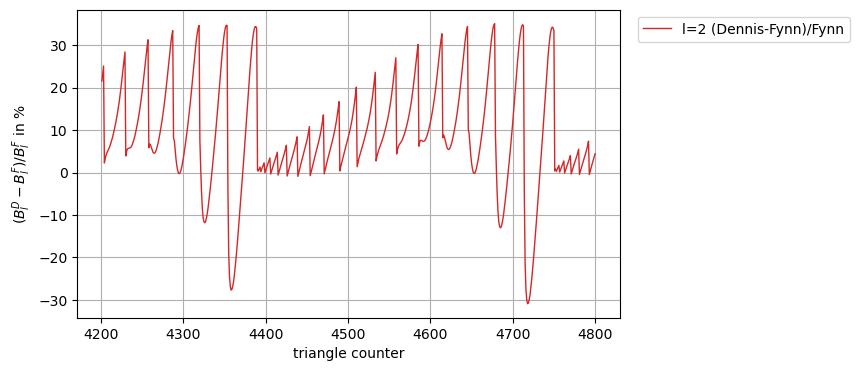

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(n_triag[4200:4800], 100*(B0_diff[4200:4800]-B2_diff[4200:4800])/B0_diff[4200:4800], linewidth=1, color=colors[0], label="l=2 (Dennis-Fynn)/Dennis")

plt.xlabel("triangle counter")
plt.ylabel("$(B_l^D-B_l^F)/B_l^D$ in %")
plt.grid()
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))  # Moves legend outside
plt.savefig("bisepctrum_verlgeich", bbox_inches="tight")
plt.show()

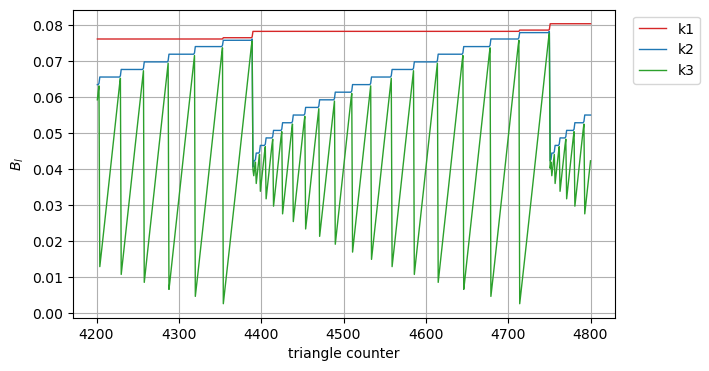

In [10]:
# k-space
plt.figure(figsize=(7, 4))
plt.plot(n_triag[4200:4800], (k1_arr[4200:4800]), linewidth=1, color=colors[0], label="k1")
plt.plot(n_triag[4200:4800], (k2_arr[4200:4800]), linewidth=1, color=colors[1], label="k2")
plt.plot(n_triag[4200:4800], (k3_arr[4200:4800]), linewidth=1, color=colors[2], label="k3")
#plt.plot(n_triag[4200:4800], (B2_diff[4200:4800]+5e8)*1.2, linewidth=1, color=colors[1], label="l=0 Fynn")
#plt.plot(n_triag, B4_diff, linewidth=0.5, color=colors[2], marker=".", label="l=4")


#plt.yscale("log")
plt.xlabel("triangle counter")
plt.ylabel("$B_l$")
plt.grid()
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))  # Moves legend outside
plt.savefig("bisepctrum_verlgeich", bbox_inches="tight")
plt.show()

In [11]:
# optional: reset parameters to default in case you want 
# to set different parameters and rerun LambdaCDM.compute()
LambdaCDM.empty()

In [12]:
import numpy as np
from numpy.polynomial.legendre import leggauss


# Example usage
n = 10
nodes, weights = leggauss(n)
print("Nodes:", nodes)
print("Weights:", weights)


Nodes: [-0.97390653 -0.86506337 -0.67940957 -0.43339539 -0.14887434  0.14887434
  0.43339539  0.67940957  0.86506337  0.97390653]
Weights: [0.06667134 0.14945135 0.21908636 0.26926672 0.29552422 0.29552422
 0.26926672 0.21908636 0.14945135 0.06667134]
